In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn import datasets

In [3]:
data = datasets.load_iris()
iris = pd.DataFrame(data.data, columns=data.feature_names)
iris['species'] = data.target
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [4]:
iris = iris.rename(columns={'sepal length (cm)': 'sl', 'sepal width (cm)': 'sw', 'petal length (cm)': 'pl', 'petal width (cm)': 'pw'})

In [5]:
iris_2species = iris[ (iris.species == 1) | (iris.species == 2) ]

In [ ]:
X = iris_2species[['pl']]
y = iris_2species['species']

In [13]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression().fit(X, y)
lr.intercept_, lr.coef_

(array([-17.55814728]), array([[2.77980871, 2.38512529]]))

In [14]:
lr_beta0 = lr.intercept_[0]
lr_beta1 = lr.coef_[0][0]
lr_threshold = -lr_beta0 / lr_beta1
(lr_beta0, lr_beta1, lr_threshold)

(np.float64(-17.558147282793193),
 np.float64(2.7798087107418334),
 np.float64(6.3163149374071645))

In [9]:
X1 = X[y==1].to_numpy()
X2 = X[y==2].to_numpy()

mu1 = np.mean(X1)
mu2 = np.mean(X2)

var1 = np.var(X1)
var2 = np.var(X2)

var = np.mean([var1, var2])

ax_beta0 = (mu1 ** 2 - mu2 **2)/2/var
ax_beta1 = (mu2 - mu1)/var
ax_threshold =  -ax_beta0 / ax_beta1
(ax_beta0, ax_beta1, ax_threshold)


(np.float64(-24.62070787110408),
 np.float64(5.0184891706286345),
 np.float64(4.906))

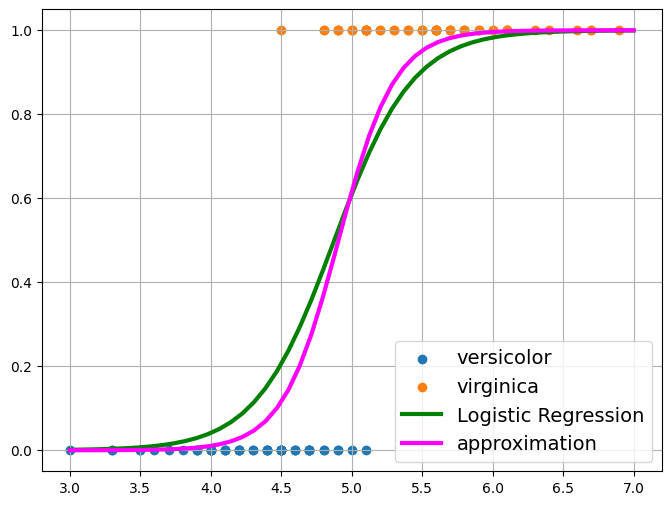

In [10]:
def sigmoid(beta0, beta1, x):
    return 1 / (1 + np.exp(-(beta0 + beta1 * x)))

x = np.linspace(3, 7)

plt.figure(figsize=(8,6))
plt.scatter(X1, np.zeros(50), label='versicolor')
plt.scatter(X2, np.ones(50), label='virginica')
plt.plot(x, sigmoid(lr_beta0, lr_beta1, x), linewidth=3, color='green', label='Logistic Regression')
plt.plot(x, sigmoid(ax_beta0, ax_beta1, x), linewidth=3, color='magenta', label='approximation')
plt.legend(fontsize=14)
plt.grid()


In [ ]:
X 